# Anomaly Plot: VIIRS 2025 - VIIRS 2012-2025 Climatology

In [1]:
pip install cmocean

  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)
Note: you may need to restart the kernel to use updated packages.


In [2]:
import earthaccess
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import numpy as np
import matplotlib.animation as animation
import os
from PIL import Image, ImageEnhance
import pandas as pd
import scipy.stats as scipy
import matplotlib.patches as mpatches
import cartopy.feature as cfeature
from netCDF4 import Dataset
import cmocean

# Plot Individual Data

## Get climatology datasets

In [18]:
# set dataframes
clima_kd490_jan = xr.open_dataset('/home/jovyan/Desktop/data/kd490_clima_VIIRS/SNPP_VIIRS.20120101_20250131.L3m.MC.KD.x_Kd_490.nc', engine = 'netcdf4') # january
clima_kd490_feb = xr.open_dataset('/home/jovyan/Desktop/data/kd490_clima_VIIRS/SNPP_VIIRS.20120201_20250228.L3m.MC.KD.x_Kd_490.nc', engine = 'netcdf4') # february
# chlorophyll:
clima_chla_jan = xr.open_dataset('/home/jovyan/Desktop/data/chla_clima_VIIRS/SNPP_VIIRS.20120101_20250131.L3m.MC.CHL.x_chlor_a.nc', engine = 'netcdf4')
clima_chla_feb = xr.open_dataset('/home/jovyan/Desktop/data/chla_clima_VIIRS/SNPP_VIIRS.20120201_20250228.L3m.MC.CHL.x_chlor_a.nc', engine = 'netcdf4')

In [39]:
# set toi
clima = clima_chla_feb
# title purposes later
month = 'February'
chla,chlashort = 'Chlorophyll-a (mg m$^{-3}$)', 'Chlorophyll-a'
kd490,kdshort = 'Diffuse Attenuation at 490 nm (Kd490) (m$^{-1}$)',  'Kd490'
variable = chla
variable_short = chlashort

In [40]:
climo_data = clima['chlor_a'][:]
#climo_data = clima['Kd_490'][:]
#climo_chla #.plot(vmin = 0.05, vmax = 0.5)
climo_data

<xarray.DataArray 'chlor_a' (lat: 841, lon: 1404)> Size: 5MB
[1180764 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB 42.3 42.26 42.22 42.17 ... 7.394 7.352 7.311
  * lon      (lon) float32 6kB -160.1 -160.1 -160.1 ... -101.8 -101.7 -101.7
Attributes:
    long_name:      Chlorophyll Concentration, OCI Algorithm
    units:          mg m^-3
    standard_name:  mass_concentration_of_chlorophyll_in_sea_water
    valid_min:      0.001
    valid_max:      100.0
    reference:      Hu, C., Lee Z., and Franz, B.A. (2012). Chlorophyll-a alg...
    display_scale:  log
    display_min:    0.01
    display_max:    20.0

## Get 2025 virrs snpp data

In [41]:
# Enter login information for NASA Earthdata
auth = earthaccess.login(persist=True)
# Search the dataset for an instrument you want to work with
results = earthaccess.search_datasets(instrument = 'viirs', keyword = 'kd') #instrument="aqua") # oci
# For an index (item) in results (the dataset), print the associated products (the summary)
    # In this, you will see the products available from your selected instrument
for item in results:
    summary = item.summary()
    print(summary["short-name"])

VIIRSJ1_L3b_KD
VIIRSJ1_L3b_KD_NRT
VIIRSJ1_L3m_KD
VIIRSJ1_L3m_KD_NRT
VIIRSJ2_L3b_KD
VIIRSJ2_L3b_KD_NRT
VIIRSJ2_L3m_KD
VIIRSJ2_L3m_KD_NRT
VIIRSN_L3b_KD
VIIRSN_L3b_KD_NRT
VIIRSN_L3m_KD
VIIRSN_L3m_KD_NRT


In [42]:
kd = "VIIRSN_L3m_KD"
chl = "VIIRSN_L3m_CHL"
shortname = chl

In [43]:
# identifying different timespans
jan = ("2025-01-01", "2025-01-31") 
feb = ("2025-02-01", "2025-02-28") 

In [44]:
tspan = feb
lon_min, lon_max = min(clima['lon']), max(clima['lon'])
lat_min, lat_max =  min(clima['lat']), max(clima['lat']) 
bbox = (lon_min, lat_min, lon_max, lat_max) # bbox = 'bounding box' so change this to the lat, lon you want to investigate -- originally was (-75, 35, -70, 38)
clouds = (0,20) #change to (0,100) to see all satellite images that include cloud cover

In [45]:
results = earthaccess.search_data(
    short_name=shortname, #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.M*.4km*", # daily 4 km data
    temporal=tspan,
    bounding_box=bbox
)
paths = earthaccess.open(results)

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

In [46]:
for p in paths:
    print(p.key)

SNPP_VIIRS.20120201_20250228.L3m.MC.CHL.chlor_a.4km.nc
SNPP_VIIRS.20120301_20250331.L3m.MC.CHL.chlor_a.4km.nc
SNPP_VIIRS.20250201_20250228.L3m.MO.CHL.chlor_a.4km.nc


In [47]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

In [48]:
# get the MO data for Jan/Feb
ds_2025 = xr.open_dataset(paths[-1])
ds_2025

<xarray.Dataset> Size: 149MB
Dimensions:  (lat: 4320, lon: 8640, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 17kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float32 35kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 149MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      SNPP_VIIRS.20250201_20250228.L3m.MO.CH...
    instrument:                        VIIRS
    title:                             VIIRSN Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Suomi-NPP
    source:                            satellite observations from VIIRS-Suom...
    ...                                ...
    identifier_product_doi:            10.5067/SUOMI-NPP/VIIRS/L3M/CHL/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         19702421
    data_minimum:                      0.001
    data_maximum:                      99.75742

In [49]:
# create a dataset that selects the points in my ROI
dataset_masked = ds_2025.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
data_2025 = dataset_masked['chlor_a']
data_2025

<xarray.DataArray 'chlor_a' (lat: 840, lon: 1403)> Size: 5MB
[1178520 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 3kB 42.27 42.23 42.19 42.15 ... 7.396 7.354 7.312
  * lon      (lon) float32 6kB -160.1 -160.1 -160.1 ... -101.8 -101.8 -101.7
Attributes:
    long_name:      Chlorophyll Concentration, OCI Algorithm
    units:          mg m^-3
    standard_name:  mass_concentration_of_chlorophyll_in_sea_water
    valid_min:      0.001
    valid_max:      100.0
    reference:      Hu, C., Lee Z., and Franz, B.A. (2012). Chlorophyll-a alg...
    display_scale:  log
    display_min:    0.01
    display_max:    20.0

In [50]:
# since the dimensions are off by 1 number each, we will interpolate
climo_interp = climo_data.interp(
    lat = data_2025.lat,
    lon = data_2025.lon,
    method = "nearest"  
)

In [51]:
anomaly = data_2025 - climo_interp
anomaly

<xarray.DataArray 'chlor_a' (lat: 840, lon: 1403)> Size: 5MB
array([[-0.0218561 , -0.03735271, -0.04778165, ...,         nan,
                nan,         nan],
       [-0.01293927, -0.04639037, -0.07336074, ...,         nan,
                nan,         nan],
       [-0.03910837, -0.05946961, -0.08773364, ...,         nan,
                nan,         nan],
       ...,
       [ 0.03317551,  0.0315275 ,  0.03286859, ..., -0.03748618,
        -0.03688644, -0.03291225],
       [ 0.03163198,  0.03172176,  0.02164758, ..., -0.03526722,
        -0.03555109, -0.03280483],
       [ 0.01544403,  0.03275431,  0.03527337, ..., -0.0291246 ,
        -0.02708016, -0.02728947]], dtype=float32)
Coordinates:
  * lat      (lat) float32 3kB 42.27 42.23 42.19 42.15 ... 7.396 7.354 7.312
  * lon      (lon) float32 6kB -160.1 -160.1 -160.1 ... -101.8 -101.8 -101.7

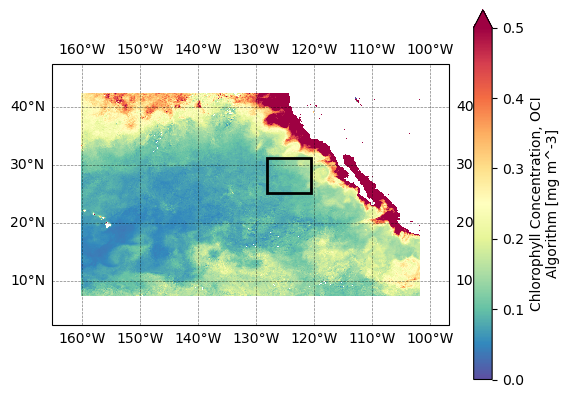

In [21]:
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = data_2025.plot(
    ax=ax,
    cmap = 'Spectral_r', vmin = 0, vmax=0.5, 
    transform=ccrs.PlateCarree()
)

lon_min_1, lon_max_1 = -128.045, -120.517 #og
lat_min_1, lat_max_1 = 25.179, 31.164 #og
width_1 = lon_max_1 - lon_min_1 
height_1 = lat_max_1 - lat_min_1
ax.add_patch(mpatches.Rectangle(xy=[lon_min_1, lat_min_1], width=width_1, height=height_1,facecolor='none', edgecolor='k', linewidth = 2,transform=ccrs.PlateCarree()))


ax.set_ylim([lat_min-5, lat_max+5])
ax.set_xlim([lon_min-5, lon_max+5])
gl = ax.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')

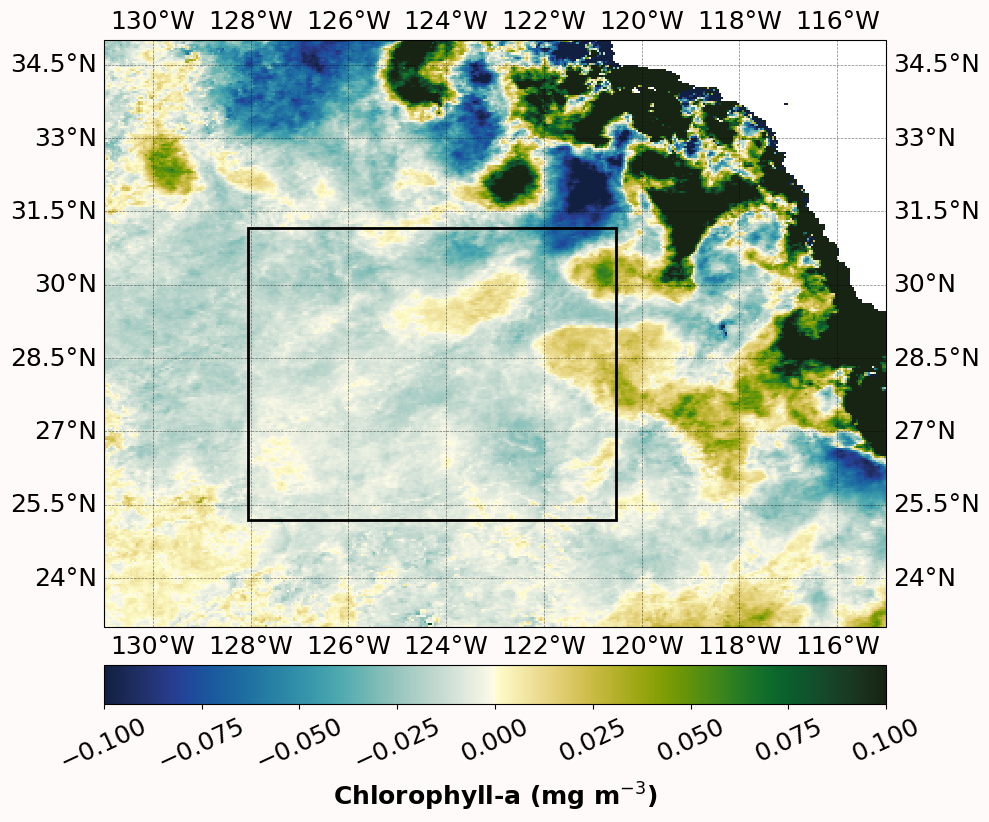

In [52]:
fig = plt.figure(figsize = (10,10), facecolor = 'snow')
#fig = plt.figure(figsize = (8,8), facecolor = 'snow')

ax = plt.axes(projection=ccrs.PlateCarree())

mesh = anomaly.plot(
    ax=ax,
    cmap = 'cmo.delta', vmin = -0.1, vmax=0.1, # curl or tarn for kd490, delta for chl-a (vmin = 0.2 and -0.2 for chl-a)
    transform=ccrs.PlateCarree(), add_colorbar = False
)

# create the colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.04)
cbar.set_label(f'{variable}', fontsize=18, fontweight = 'bold')

cbar.ax.tick_params(labelsize=18, rotation = 25)
gl = ax.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}
#ax.set_extent([-140, -110, 20, 38])
ax.set_extent([-131, -115, 23, 35])

lon_min_1, lon_max_1 = -128.045, -120.517 #og
lat_min_1, lat_max_1 = 25.179, 31.164 #og
width_1 = lon_max_1 - lon_min_1 
height_1 = lat_max_1 - lat_min_1
ax.add_patch(mpatches.Rectangle(xy=[lon_min_1, lat_min_1], width=width_1, height=height_1,facecolor='none', edgecolor='k', linewidth = 2,transform=ccrs.PlateCarree()))
#ax.scatter(-118.54, 34.07, marker='*', s=500, color='gold', edgecolor='k', zorder=10, label = 'Pacific Palisades, CA')

#plt.title(f'{month} 2025 versus {month} 2012-2025 Climatology {variable_short} Anomalies', fontsize = 15, fontweight = 'bold', pad = 15)
plt.tight_layout()
plt.savefig(f'/home/jovyan/Desktop/figures/anomalies/shrunk_{month}_{variable_short}_anomalies_2025_vs_2012--2025', bbox_inches = 'tight', dpi = 300)

## Feb - Jan maps

In [ ]:
clima_jan = xr.open_dataset('/home/jovyan/Desktop/data/kd490_clima_VIIRS/SNPP_VIIRS.20120101_20250131.L3m.MC.KD.x_Kd_490.nc', engine = 'netcdf4') # january
climo_chla_jan = clima_jan['Kd_490'][:]

clima_feb = xr.open_dataset('/home/jovyan/Desktop/data/kd490_clima_VIIRS/SNPP_VIIRS.20120201_20250228.L3m.MC.KD.x_Kd_490.nc', engine = 'netcdf4')
climo_chla_feb = clima_feb['Kd_490'][:]
climo_chla_feb

### JANUARY

In [ ]:
# Enter login information for NASA Earthdata
auth = earthaccess.login(persist=True)
# Search the dataset for an instrument you want to work with
results_jan = earthaccess.search_datasets(instrument = 'viirs', keyword = 'kd') #instrument="aqua") # oci
# For an index (item) in results (the dataset), print the associated products (the summary)

tspan = ("2025-01-01", "2025-01-31") 
lon_min, lon_max = min(clima_jan['lon']), max(clima_jan['lon'])
lat_min, lat_max =  min(clima_jan['lat']), max(clima_jan['lat']) 
bbox = (lon_min, lat_min, lon_max, lat_max) # bbox = 'bounding box' so change this to the lat, lon you want to investigate -- originally was (-75, 35, -70, 38)
clouds = (0,20) #change to (0,100) to see all satellite images that include cloud cover

results_jan = earthaccess.search_data(
    short_name="VIIRSN_L3m_KD", #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.M*.4km*", # daily 4 km data
    temporal=tspan,
    bounding_box=bbox
)

paths_jan = earthaccess.open(results_jan) #'streaming' data

In [ ]:
# get the MO data for Jan/Feb
ds_2025_jan = xr.open_dataset(paths_jan[-1])
ds_2025_jan

In [ ]:
# create a dataset that selects the points in my ROI
dataset_masked_jan = ds_2025_jan.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
chla_2025_jan = dataset_masked_jan['Kd_490']
chla_2025_jan

In [ ]:
# since the dimensions are off by 1 number each, we will interpolate
climo_interp_jan = climo_chla_jan.interp(
    lat = chla_2025_jan.lat,
    lon = chla_2025_jan.lon,
    method = "nearest"  
)
anomaly_jan = chla_2025_jan - climo_interp_jan
anomaly_jan

### FEBRUARY

In [ ]:
# Enter login information for NASA Earthdata
auth = earthaccess.login(persist=True)
# Search the dataset for an instrument you want to work with
results_feb = earthaccess.search_datasets(instrument = 'viirs', keyword = 'kd') #instrument="aqua") # oci
# For an index (item) in results (the dataset), print the associated products (the summary)

tspan = ("2025-02-01", "2025-02-28") 
lon_min, lon_max = min(clima_feb['lon']), max(clima_feb['lon'])
lat_min, lat_max =  min(clima_feb['lat']), max(clima_feb['lat']) 
bbox = (lon_min, lat_min, lon_max, lat_max) # bbox = 'bounding box' so change this to the lat, lon you want to investigate -- originally was (-75, 35, -70, 38)
clouds = (0,20) #change to (0,100) to see all satellite images that include cloud cover

results_feb = earthaccess.search_data(
    short_name="VIIRSN_L3m_KD", #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.M*.4km*", # daily 4 km data
    temporal=tspan,
    bounding_box=bbox
)

paths_feb = earthaccess.open(results_feb) #'streaming' data

In [ ]:
# get the MO data for Jan/Feb
ds_2025_feb = xr.open_dataset(paths_feb[-1])
# create a dataset that selects the points in my ROI
dataset_masked_feb = ds_2025_feb.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
chla_2025_feb = dataset_masked_feb['Kd_490']

# since the dimensions are off by 1 number each, we will interpolate
climo_interp_feb = climo_chla_feb.interp(
    lat = chla_2025_feb.lat,
    lon = chla_2025_feb.lon,
    method = "nearest"  
)
anomaly_feb = chla_2025_feb - climo_interp_feb
anomaly_feb

In [ ]:
anomalies_feb_jan = anomaly_feb - anomaly_jan
anomalies_feb_jan

### PLOT

In [ ]:
fig = plt.figure(figsize = (10,10), facecolor = 'snow')
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = anomalies_feb_jan.plot(
    ax=ax,
    cmap = 'bwr', vmin = -0.01, vmax=0.01, 
    transform=ccrs.PlateCarree(), add_colorbar = False
)

# create the colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.03)
cbar.set_label(f'{variable}', fontsize=13, fontweight = 'bold')

cbar.ax.tick_params(labelsize=12)
gl = ax.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 12}
gl.ylabel_style = {'size': 12}
ax.set_extent([-140, -110, 20, 38])


lon_min_1, lon_max_1 = -128.045, -120.517 #og
lat_min_1, lat_max_1 = 25.179, 31.164 #og
width_1 = lon_max_1 - lon_min_1 
height_1 = lat_max_1 - lat_min_1
ax.add_patch(mpatches.Rectangle(xy=[lon_min_1, lat_min_1], width=width_1, height=height_1,facecolor='none', edgecolor='k', linewidth = 2,transform=ccrs.PlateCarree()))

plt.title('February -- January 2025 versus 2012-2025 Climatology Kd490 Anomalies', fontsize = 15, fontweight = 'bold', pad = 15)
plt.tight_layout()
plt.savefig('/home/jovyan/Desktop/figures/anomalies/Feb-Jan_kd490_anomalies_2025_vs_2012--2025', bbox_inches = 'tight', dpi = 300)

# Plot Ratioed Data: POC:CHLOROPHYLL-A

## Climatology Data

In [3]:
# get climatology dataset
clima_chla_march = xr.open_dataset('/home/jovyan/Desktop/data/new_chla_climo_inpres/SNPP_VIIRS.20120301_20250331.L3m.MC.CHL.x_chlor_a.nc', engine = 'netcdf4') 
clima_chla_feb = xr.open_dataset('/home/jovyan/Desktop/data/new_chla_climo_inpres/SNPP_VIIRS.20120201_20250228.L3m.MC.CHL.x_chlor_a.nc', engine = 'netcdf4') 
clima_chla_jan = xr.open_dataset('/home/jovyan/Desktop/data/new_chla_climo_inpres/SNPP_VIIRS.20120101_20250131.L3m.MC.CHL.x_chlor_a.nc')
clima_chla_dec = xr.open_dataset('/home/jovyan/Desktop/data/new_chla_climo_inpres/SNPP_VIIRS.20121201_20241231.L3m.MC.CHL.x_chlor_a.nc')
clima_chla = clima_chla_feb

clima_poc_march = xr.open_dataset('/home/jovyan/Desktop/data/POC_clima_VIIRS/SNPP_VIIRS.20120301_20250331.L3m.MC.POC.x_poc.nc', engine = 'netcdf4') 
clima_poc_feb = xr.open_dataset('/home/jovyan/Desktop/data/POC_clima_VIIRS/SNPP_VIIRS.20120201_20250228.L3m.MC.POC.x_poc.nc', engine = 'netcdf4') # poc
clima_poc_jan = xr.open_dataset('/home/jovyan/Desktop/data/POC_clima_VIIRS/SNPP_VIIRS.20120101_20250131.L3m.MC.POC.x_poc.nc', engine = 'netcdf4') # poc
clima_poc_dec = xr.open_dataset('/home/jovyan/Desktop/data/POC_clima_VIIRS/SNPP_VIIRS.20121201_20241231.L3m.MC.POC.x_poc.nc', engine = 'netcdf4') # poc # dec

clima_poc = clima_poc_feb

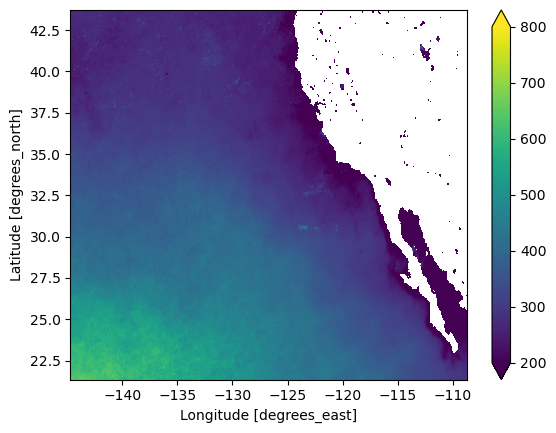

In [4]:
#climo_ratio = clima_chla_jan['chlor_a'] / clima_poc_jan['poc']
climo_ratio = clima_poc['poc'] / clima_chla['chlor_a']
climo_ratio.plot(vmin=200,vmax=800)

## Get VIIRS Data

In [5]:
# Enter login information for NASA Earthdata
auth = earthaccess.login(persist=True)
# Search the dataset for an instrument you want to work with
results = earthaccess.search_datasets(instrument = 'viirs', keyword = 'chlorophyll') #instrument="aqua") # oci
# For an index (item) in results (the dataset), print the associated products (the summary)
    # In this, you will see the products available from your selected instrument
for item in results:
    summary = item.summary()
    print(summary["short-name"])

VIIRSJ1_L3b_CHL
VIIRSJ1_L3b_CHL_NRT
VIIRSJ1_L3m_CHL
VIIRSJ1_L3m_CHL_NRT
VIIRSJ2_L3b_CHL
VIIRSJ2_L3b_CHL_NRT
VIIRSJ2_L3m_CHL
VIIRSJ2_L3m_CHL_NRT
VIIRSN_L3b_CHL
VIIRSN_L3b_CHL_NRT
VIIRSN_L3m_CHL
VIIRSN_L3m_CHL_NRT
VIIRSJ1_L2_OC
VIIRSJ1_L2_OC_NRT
VIIRSJ2_L2_OC
VIIRSJ2_L2_OC_NRT
VIIRSN_L2_OC
VIIRSN_L2_OC_NRT
VNP13A2
VNP13A1
VJ113A1
VJ113A2
VNP13A3
VNP13C2
VJ113A3
VJ113C1
VJ113C2
VNP13C1
VNP13A1
VNP13A2
VNP13C1
VNP13A3
VNP13C2


In [72]:
# identifying different timespans
dec = ("2024-12-01", "2024-12-31")
jan = ("2025-01-01", "2025-01-31") 
feb = ("2025-02-01", "2025-02-28") 
mar = ("2025-03-01","2025-03-31")
janu24 = ("2024-01-01", "2024-01-31") 
dece = 'December'
janu = 'January'
febr = 'February'
marc = 'March'
month = febr

In [75]:
tspan = feb
lon_min, lon_max = min(climo_ratio['lon']), max(climo_ratio['lon'])
lat_min, lat_max =  min(climo_ratio['lat']), max(climo_ratio['lat']) 
bbox = (lon_min, lat_min, lon_max, lat_max) # bbox = 'bounding box' so change this to the lat, lon you want to investigate -- originally was (-75, 35, -70, 38)
clouds = (0,20) #change to (0,100) to see all satellite images that include cloud cover

In [76]:
results_chla = earthaccess.search_data(
    short_name='VIIRSN_L3m_CHL', #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.M*.4km*", # daily 4 km data
    temporal=tspan,
    bounding_box=bbox
)
#paths_chla = earthaccess.open(results_chla)

results_poc = earthaccess.search_data(
    short_name='VIIRSN_L3m_POC', #.DAY.CHL.chlor_a.4km.nc   
    granule_name="*.M*.4km*", # daily 4 km data
    temporal=tspan,
    bounding_box=bbox
)
#paths_poc = earthaccess.open(results_poc)

In [77]:
paths_chla = earthaccess.open(results_chla) #'streaming' data
paths_poc = earthaccess.open(results_poc) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

In [78]:
# chla: get the MO data for Jan/Feb
ds_2025_chla = xr.open_dataset(paths_chla[-1])
# create a dataset that selects the points in my ROI
dataset_masked_chla = ds_2025_chla.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
data_2025_chla = dataset_masked_chla['chlor_a']
data_2025_chla

# poc: get the MO data for Jan/Feb
ds_2025_poc = xr.open_dataset(paths_poc[-1])
# create a dataset that selects the points in my ROI
dataset_masked_poc = ds_2025_poc.sel(lon=slice(bbox[0], bbox[2]),lat=slice(bbox[3], bbox[1]))
data_2025_poc = dataset_masked_poc['poc']
data_2025_poc

<xarray.DataArray 'poc' (lat: 536, lon: 863)> Size: 2MB
[462568 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 2kB 43.69 43.65 43.6 43.56 ... 21.52 21.48 21.44 21.4
  * lon      (lon) float32 3kB -144.6 -144.6 -144.6 ... -108.8 -108.8 -108.7
Attributes:
    long_name:      Particulate Organic Carbon, D. Stramski, 2007 (443/555 ve...
    units:          mg m^-3
    valid_min:      -32000
    valid_max:      -27000
    reference:      Stramski, D., et al. "Relationships between the surface c...
    display_scale:  log
    display_min:    10.0
    display_max:    1000.0

In [79]:
#ratio_2025 = data_2025_chla/data_2025_poc
ratio_2025 = data_2025_poc/data_2025_chla
ratio_2025

<xarray.DataArray (lat: 536, lon: 863)> Size: 2MB
array([[268.2339 , 262.4874 , 257.32892, ...,       nan,       nan,
              nan],
       [260.9807 , 258.762  , 268.71283, ...,       nan,       nan,
              nan],
       [270.1555 , 276.7779 , 281.6793 , ...,       nan,       nan,
              nan],
       ...,
       [646.2174 , 662.50195, 662.8249 , ..., 280.3267 , 276.88287,
        275.66153],
       [638.28687, 643.21344, 646.1465 , ..., 283.11755, 280.7216 ,
        281.5049 ],
       [623.0403 , 619.1073 , 633.64606, ..., 286.5653 , 284.35925,
        285.48987]], dtype=float32)
Coordinates:
  * lat      (lat) float32 2kB 43.69 43.65 43.6 43.56 ... 21.52 21.48 21.44 21.4
  * lon      (lon) float32 3kB -144.6 -144.6 -144.6 ... -108.8 -108.8 -108.7

In [80]:
# since the dimensions are off by 1 number each, we will interpolate
climo_ratio_interp = climo_ratio.interp(
    lat=ratio_2025.lat,
    lon=ratio_2025.lon,
    method='linear'
)

## Create anomaly

In [81]:
anomaly = ratio_2025 - climo_ratio_interp
anomaly

<xarray.DataArray (lat: 536, lon: 863)> Size: 2MB
array([[ -8.043457  , -12.91333   , -18.715668  , ...,          nan,
                 nan,          nan],
       [-13.526672  , -14.713318  ,  -5.5825806 , ...,          nan,
                 nan,          nan],
       [ -0.08303833,   6.4030457 ,   9.369385  , ...,          nan,
                 nan,          nan],
       ...,
       [  4.1765137 ,  18.102417  ,  19.163635  , ...,  -8.012695  ,
         -9.396301  ,  -9.160706  ],
       [ -6.71167   ,   1.7913208 ,   4.2506104 , ...,  -3.8300781 ,
         -4.931671  ,  -4.76828   ],
       [-21.981812  , -23.534363  , -11.869873  , ...,   0.07049561,
         -1.8556519 ,  -1.4442749 ]], dtype=float32)
Coordinates:
  * lat      (lat) float32 2kB 43.69 43.65 43.6 43.56 ... 21.52 21.48 21.44 21.4
  * lon      (lon) float32 3kB -144.6 -144.6 -144.6 ... -108.8 -108.8 -108.7

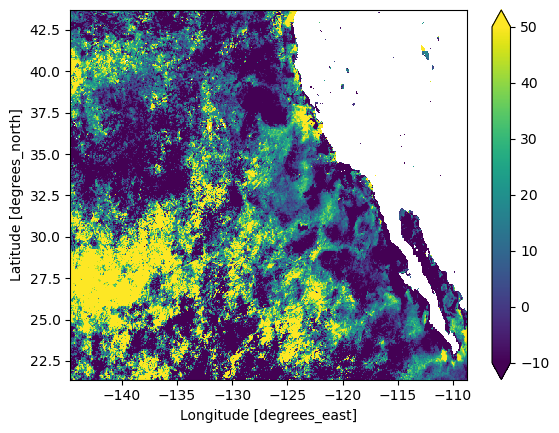

In [82]:
#anomaly.plot(vmin = -0.002, vmax = 0.002)
anomaly.plot(vmin = -10, vmax = 50)

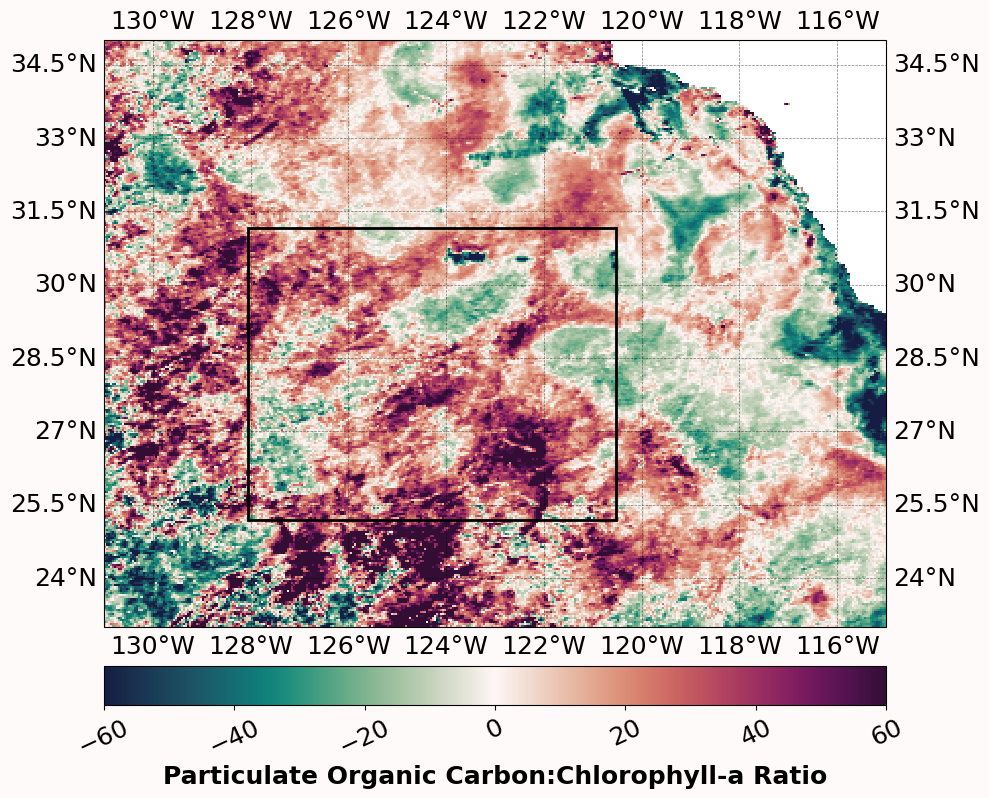

In [83]:
fig = plt.figure(figsize = (10,10), facecolor = 'snow')
#fig = plt.figure(figsize = (8,8), facecolor = 'snow')
ax = plt.axes(projection=ccrs.PlateCarree())

mesh = anomaly.plot(
    ax=ax,
    cmap = 'cmo.curl', vmin = -60, vmax=60,  # vmin = -0.001, vmax=0.001, # curl for kd490, delta for chl-a (vmin = 0.2 and -0.2 for chl-a)
    transform=ccrs.PlateCarree(), add_colorbar = False
)

# create the colorbar
cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.04)
#cbar.set_label('Chlorophyll-a:Particulate Organic Carbon Ratio', fontsize=13, fontweight = 'bold')
cbar.set_label('Particulate Organic Carbon:Chlorophyll-a Ratio', fontsize=18, fontweight = 'bold')

cbar.ax.tick_params(labelsize=18, rotation=25)
gl = ax.gridlines(draw_labels = True, color = 'k', alpha=0.5, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'size': 18}
gl.ylabel_style = {'size': 18}
#ax.set_extent([-140, -110, 20, 38])
ax.set_extent([-131, -115, 23, 35])


lon_min_1, lon_max_1 = -128.045, -120.517 #og
lat_min_1, lat_max_1 = 25.179, 31.164 #og
width_1 = lon_max_1 - lon_min_1 
height_1 = lat_max_1 - lat_min_1
ax.add_patch(mpatches.Rectangle(xy=[lon_min_1, lat_min_1], width=width_1, height=height_1,facecolor='none', edgecolor='k', linewidth = 2,transform=ccrs.PlateCarree()))

#plt.title(f'{month} 2025 versus {month} 2012-2025 Climatology Chlorophyll-a:Particulate Organic Carbon Anomalies', fontsize = 15, fontweight = 'bold', pad = 15)
#plt.title(f'{month} 2025 versus {month} 2012-2025 Climatology POC:Chl-a Anomalies', fontsize = 15, fontweight = 'bold', pad = 15)
plt.tight_layout()
plt.savefig(f'/home/jovyan/Desktop/figures/anomalies/shrunk_{month}_poc_chla_anomalies_2025_vs_2012--2025', bbox_inches = 'tight', dpi = 300)